从给定的CSV文件读取数据并生成Spark数据框架

In [1]:
import os
os.environ["JAVA_HOME"] = "C:\\Program Files\\JDK1.8"
os.environ["SPARK_HOME"] = "C:\\spark-3.4.0-bin-without-hadoop"

In [3]:
from pyspark.sql import SparkSession

# 使用现代Spark初始化方式
spark = SparkSession.builder \
    .appName("MyApp") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.network.timeout", "1800s") \
    .getOrCreate()

输出数据的前10行

In [4]:
df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("file:///D:/code/python/BigDataDevelopment/myCode/Homework4_datasets/epi_r.csv")

df.limit(10).toPandas()

,title,rating,calories,protein,fat,sodium,#cakeweek,#wasteless,22-minute meals,3-ingredient recipes,...,yellow squash,yogurt,yonkers,yuca,zucchini,cookbooks,leftovers,snack,snack week,turkey
0,"Lentil, Apple, and Turkey Wrap",2.5,426.0,30.0,7.0,559.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Boudin Blanc Terrine with Red Onion Confit,4.375,403.0,18.0,23.0,1439.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Potato and Fennel Soup Hodge,3.75,165.0,6.0,7.0,165.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Mahi-Mahi in Tomato Olive Sauce,5.0,None,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Spinach Noodle Casserole,3.125,547.0,20.0,32.0,452.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,The Best Blts,4.375,948.0,19.0,79.0,1042.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Ham and Spring Vegetable Salad with Shallot Vi...,4.375,None,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Spicy-Sweet Kumquats,3.75,None,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Korean Marinated Beef,4.375,170.0,7.0,10.0,1272.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Ham Persillade with Mustard Potato Salad and M...,3.75,602.0,23.0,41.0,1696.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


打印输出数据模式Schema及其变量名列表

In [5]:
df.printSchema()
print(df.columns)

root
 |-- title: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- calories: string (nullable = true)
 |-- protein: double (nullable = true)
 |-- fat: double (nullable = true)
 |-- sodium: double (nullable = true)
 |-- #cakeweek: double (nullable = true)
 |-- #wasteless: double (nullable = true)
 |-- 22-minute meals: double (nullable = true)
 |-- 3-ingredient recipes: double (nullable = true)
 |-- 30 days of groceries: double (nullable = true)
 |-- advance prep required: double (nullable = true)
 |-- alabama: double (nullable = true)
 |-- alaska: double (nullable = true)
 |-- alcoholic: double (nullable = true)
 |-- almond: double (nullable = true)
 |-- amaretto: double (nullable = true)
 |-- anchovy: double (nullable = true)
 |-- anise: double (nullable = true)
 |-- anniversary: double (nullable = true)
 |-- anthony bourdain: double (nullable = true)
 |-- aperitif: double (nullable = true)
 |-- appetizer: double (nullable = true)
 |-- apple: double (nullable = true)


打印输出数据框架的行数和列数

In [6]:
print("行数:", df.count())
print("列数:", len(df.columns))

行数: 20057
列数: 680


打印输出整个数据框架的汇总统计量，并任选两个单独的数值列输出其汇总统计量
重命名数据框架中的所有列名为规范和方便处理的名字

In [7]:
from pyspark.sql.types import NumericType

# 重命名不规范列名
new_column_names = []

for old_name in df.columns:
    new_name = old_name

    new_name = new_name.replace(',', '')
    new_name = new_name.replace('.', '')
    new_name = new_name.replace(' ', '_')
    new_name = new_name.replace('-', '_')
    new_name = new_name.replace('#', '')
    new_name = new_name.replace('&', 'and')
    new_name = new_name.replace("'", '')
    new_name = new_name.replace('(', '')
    new_name = new_name.replace(')', '')
    new_name = new_name.replace('+', '_')
    new_name = new_name.replace('/', '_or_')

    while '__' in new_name:
        new_name = new_name.replace('__', '_')

    new_name = new_name.strip('_')

    if new_name and new_name[0].isdigit():
        new_name = 'col_' + new_name

    if not new_name:
        new_name = 'unknown_column'

    new_column_names.append(new_name)

df_safe = df.toDF(*new_column_names)

In [8]:
numeric_cols = [col.name for col in df_safe.schema.fields if isinstance(col.dataType, NumericType)]
df_safe.describe(numeric_cols).show(20, truncate=False)

+-------+------------------+------------------+-----------------+-------------------+------------------+--------------------+------------------------+------------------------+---------------------+---------------------+--------------------+-------------------+-------------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+--------------------+--------------------+---------------------+-------------------+--------------------+-------------------+--------------------+---------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+--------------------+---------------------+-------------------+--------------------+---------------------+--------------------+-------------------+---------------------+--------------------+--------------------+--------------------+--------

In [9]:
if len(numeric_cols) >= 2:
    selected_cols = numeric_cols[:2]
    df_safe.describe(selected_cols).show(truncate=False)

+-------+------------------+------------------+
|summary|protein           |fat               |
+-------+------------------+------------------+
|count  |15891             |15869             |
|mean   |100.19911427852243|346.91247085512634|
|stddev |3840.1994345415883|20456.10675474679 |
|min    |0.0               |0.0               |
|max    |236489.0          |1722763.0         |
+-------+------------------+------------------+



选择两个数值型变量和一个类别型变量

In [16]:
selected_df = df_safe.select(["rating", "calories", "title"])
selected_df.show(10)

+------+--------+--------------------+
|rating|calories|               title|
+------+--------+--------------------+
|   2.5|   426.0|Lentil, Apple, an...|
| 4.375|   403.0|Boudin Blanc Terr...|
|  3.75|   165.0|Potato and Fennel...|
|   5.0|    null|Mahi-Mahi in Toma...|
| 3.125|   547.0|Spinach Noodle Ca...|
| 4.375|   948.0|      The Best Blts |
| 4.375|    null|Ham and Spring Ve...|
|  3.75|    null|Spicy-Sweet Kumqu...|
| 4.375|   170.0|Korean Marinated ...|
|  3.75|   602.0|Ham Persillade wi...|
+------+--------+--------------------+
only showing top 10 rows



任选一个类别型变量统计并输出其不同取值的个数

In [11]:
selected_df.select("title").distinct().count()

17741

将选定的两个数值型变量通过求和与求乘积生成两个新的变量

In [17]:
from pyspark.sql.functions import col
df_with_new = selected_df \
    .withColumn("sum_rating_calories", col("rating") + col("calories")) \
    .withColumn("product_rating_calories", col("rating") * col("calories"))
df_with_new.show(10)

+------+--------+--------------------+-------------------+-----------------------+
|rating|calories|               title|sum_rating_calories|product_rating_calories|
+------+--------+--------------------+-------------------+-----------------------+
|   2.5|   426.0|Lentil, Apple, an...|              428.5|                 1065.0|
| 4.375|   403.0|Boudin Blanc Terr...|            407.375|               1763.125|
|  3.75|   165.0|Potato and Fennel...|             168.75|                 618.75|
|   5.0|    null|Mahi-Mahi in Toma...|               null|                   null|
| 3.125|   547.0|Spinach Noodle Ca...|            550.125|               1709.375|
| 4.375|   948.0|      The Best Blts |            952.375|                 4147.5|
| 4.375|    null|Ham and Spring Ve...|               null|                   null|
|  3.75|    null|Spicy-Sweet Kumqu...|               null|                   null|
| 4.375|   170.0|Korean Marinated ...|            174.375|                 743.75|
|  3

从数据框架中去掉上述9）中选定的两个原始数值型变量

In [18]:
df_final = df_with_new.drop("rating", "calories")
df_final.show(10)

+--------------------+-------------------+-----------------------+
|               title|sum_rating_calories|product_rating_calories|
+--------------------+-------------------+-----------------------+
|Lentil, Apple, an...|              428.5|                 1065.0|
|Boudin Blanc Terr...|            407.375|               1763.125|
|Potato and Fennel...|             168.75|                 618.75|
|Mahi-Mahi in Toma...|               null|                   null|
|Spinach Noodle Ca...|            550.125|               1709.375|
|      The Best Blts |            952.375|                 4147.5|
|Ham and Spring Ve...|               null|                   null|
|Spicy-Sweet Kumqu...|               null|                   null|
|Korean Marinated ...|            174.375|                 743.75|
|Ham Persillade wi...|             605.75|                 2257.5|
+--------------------+-------------------+-----------------------+
only showing top 10 rows



根据选择的类别型变量对数据进行排序

In [19]:
df_sorted = df_final.orderBy("title")
df_sorted.show(10)

+--------------------+-------------------+-----------------------+
|               title|sum_rating_calories|product_rating_calories|
+--------------------+-------------------+-----------------------+
|                B...|             575.75|                 2145.0|
|                W...|               null|                   null|
|                W...|            11453.0|                    0.0|
|                W...|              870.0|                 4325.0|
|                r...|            1114.75|                4166.25|
|"""Adult"" Pimien...|               null|                   null|
|"""Blanketed"" Eg...|            1389.75|                 5197.5|
|"""Bloody Mary"" ...|              194.0|                  945.0|
|"""Brown on Blond...|              321.0|                    0.0|
|"""California Rol...|            373.375|               1614.375|
+--------------------+-------------------+-----------------------+
only showing top 10 rows



根据选择的类别型变量进行分组并对数值型变量进行聚合操作同时求每组的平均值

In [20]:
df_avg = df_final.groupBy("title").agg({"sum_rating_calories": "mean"})
df_avg.show(10)

+--------------------+------------------------+
|               title|avg(sum_rating_calories)|
+--------------------+------------------------+
|Ginger Crunch Cak...|                6845.375|
|Braised Orange Ro...|                 294.375|
|Pappardelle Bolog...|                1238.375|
|Smoked Turkey San...|                    null|
|Yukon Gold Potato...|                 366.375|
|Baked Apples with...|                 592.375|
|Roasted Yams with...|                 231.375|
|Curried Lamb Burg...|                 543.375|
|Spinach Noodle Ca...|                 550.125|
|Grilled Beef, Jíc...|                    null|
+--------------------+------------------------+
only showing top 10 rows



根据上述12）中得到的分组平均值计算平均值，然后过滤其值大于总体平均值的数据行，并仅显示生成结果的前10行

In [21]:
overall_avg = df_avg.agg({"avg(sum_rating_calories)": "mean"}).collect()[0][0]
df_filtered = df_avg.filter(col("avg(sum_rating_calories)") > overall_avg)
df_filtered.show(10)

+--------------------+------------------------+
|               title|avg(sum_rating_calories)|
+--------------------+------------------------+
|Ginger Crunch Cak...|                6845.375|
|Birthday Party Pa...|                7145.375|
|Rice Pilaf with L...|               4157362.0|
|Roast Goose with ...|                8606.125|
|Manhattan Clam Ch...|                9815.375|
|Espresso Chocolat...|                6931.375|
|Carrot Cake with ...|                  8629.0|
|Bacon-Wrapped Tro...|               12014.375|
|Lamb Köfte with T...|               4518221.0|
|Clam and Oyster C...|                  8411.0|
+--------------------+------------------------+
only showing top 10 rows



对上述13）中得到的数据框架去除重复的数据记录

In [23]:
df_dedup = df_filtered.dropDuplicates()
df_dedup.show(10)

+--------------------+------------------------+
|               title|avg(sum_rating_calories)|
+--------------------+------------------------+
|Ginger Crunch Cak...|                6845.375|
|Birthday Party Pa...|                7145.375|
|Rice Pilaf with L...|               4157362.0|
|Roast Goose with ...|                8606.125|
|Manhattan Clam Ch...|                9815.375|
|Espresso Chocolat...|                6931.375|
|Carrot Cake with ...|                  8629.0|
|Bacon-Wrapped Tro...|               12014.375|
|Lamb Köfte with T...|               4518221.0|
|Clam and Oyster C...|                  8411.0|
+--------------------+------------------------+
only showing top 10 rows



将上述14）中得到的数据框架以parquet格式输出到HDFS的相应目录

In [28]:
# 保存到绝对路径
local_path = "file:///D:/code/python/BigDataDevelopment/myCode/homework4_output"
df_dedup.write.mode("overwrite").parquet(local_path)

任选一个数值型变量生成其频数直方图

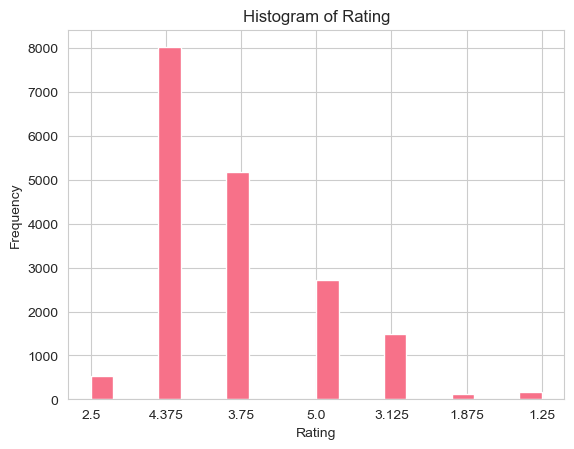

In [46]:
import matplotlib.pyplot as plt

# 过滤掉 null 值
pdf = df_safe.filter(
    (df_safe.rating.isNotNull()) &
    (df_safe.rating >= 1) &
    (df_safe.rating <= 5)
).select("rating").toPandas()

plt.hist(pdf["rating"], bins=20)
plt.title("Histogram of Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

根据选择的类别型变量对另一个选定的数值型变量绘制相应的盒型图，将生成的图片以jpg格式保存到当前目录

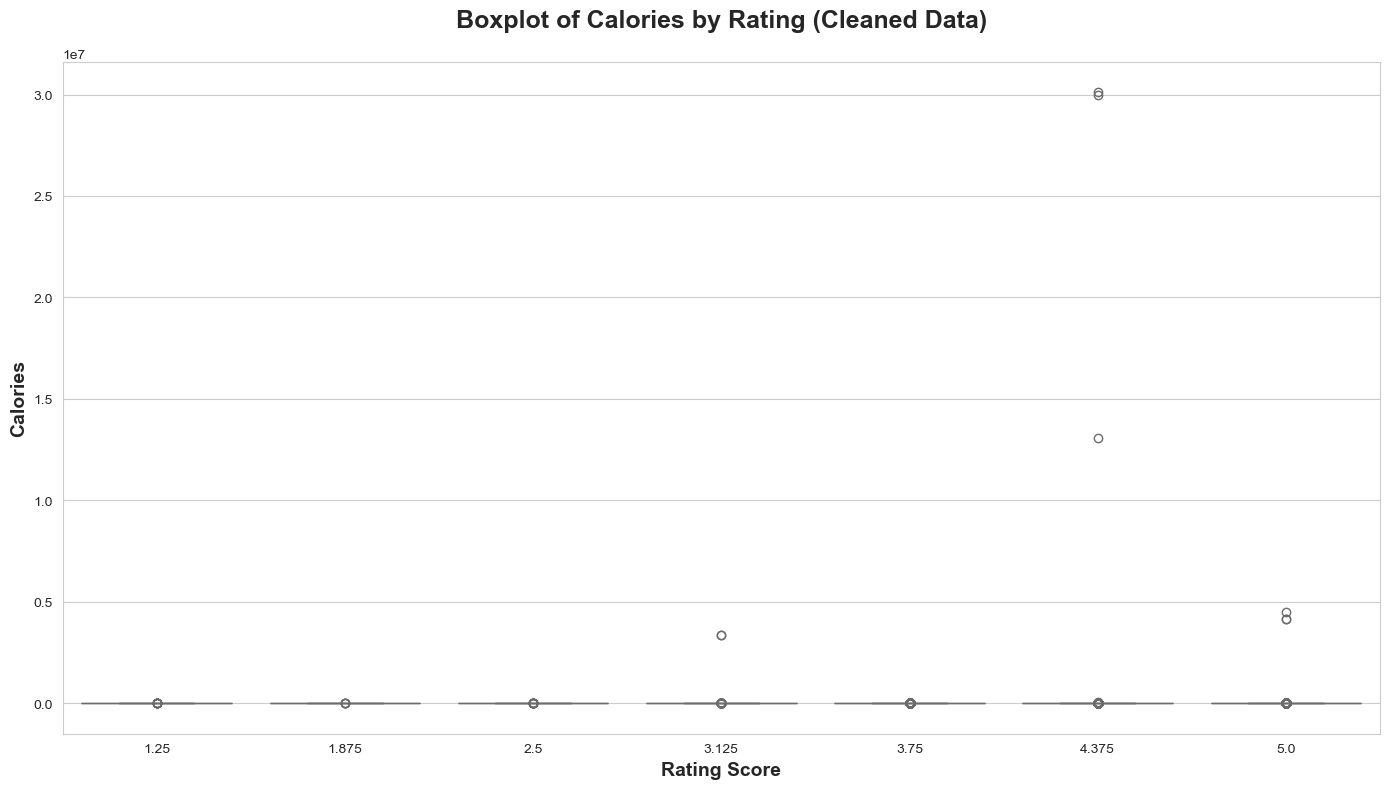

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pdf_box = df_safe.select("rating", "calories").toPandas()
pdf_box['calories'] = pd.to_numeric(pdf_box['calories'], errors='coerce')

pdf_box['rating'] = pd.to_numeric(pdf_box['rating'], errors='coerce')
pdf_box_clean = pdf_box[
    (pdf_box['rating'].notnull()) &
    (pdf_box['rating'] >= 1) &
    (pdf_box['rating'] <= 5)
    ].dropna(subset=['calories'])

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_style("whitegrid")
sns.set_palette("husl")

sns.boxplot(x="rating", y="calories", data=pdf_box_clean, ax=ax)

ax.set_title("Boxplot of Calories by Rating (Cleaned Data)", fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Rating Score", fontsize=14, fontweight='bold')
ax.set_ylabel("Calories", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [49]:
plt.savefig('calories_by_rating_boxplot.jpg',
            format='jpg',
            dpi=300,
            bbox_inches='tight',
            facecolor='white')

<Figure size 640x480 with 0 Axes>

绘制选择的类别型变量的不同取值的百分比份额的饼图

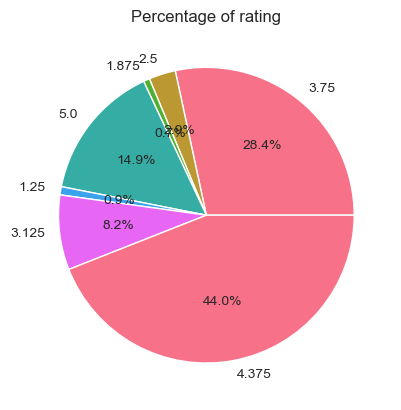

In [53]:
pdf_pie = pdf.groupBy("rating").count().toPandas()
plt.pie(pdf_pie["count"], labels=pdf_pie["rating"], autopct='%1.1f%%')
plt.title("Percentage of rating")
plt.show()

绘制选定的三个数值型变量的曲线图

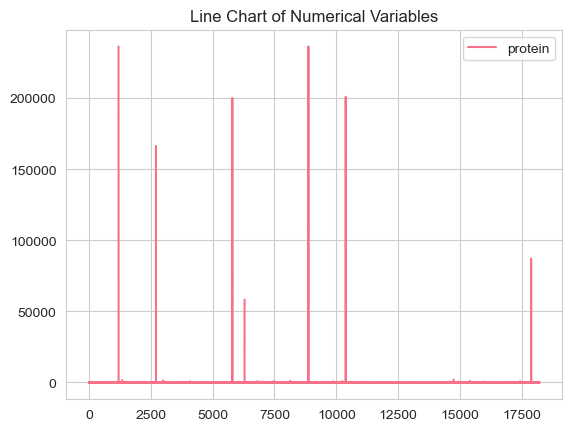

In [54]:
pdf_line = pdf.select(["rating", "calories", "protein"]).toPandas()
pdf_line.plot(kind='line')
plt.title("Line Chart of Numerical Variables")
plt.show()